In [102]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

In [103]:
import jax
jax.config.update("jax_enable_x64", True)

import jax.numpy as jnp
from flax import linen as nn
import optax
import copy

from typing import Callable

from functools import partial

import tensorflow as tf
import tensorrt

from pyDOE import lhs
import numpy as np
import matplotlib.pyplot as plt

from scipy.integrate import odeint

import numpy as np

from jax.scipy.optimize import minimize
from scipy.optimize import fsolve

import warnings
import math

from collections import deque

In [104]:
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  1


In [105]:
print(jax.default_backend())

gpu


In [106]:
def flatten_pytree(params):
  values, tree_info = jax.tree_util.tree_flatten(params)

  no_leaves = len(values)
  shapes = []
  flattened = []

  for i in range(no_leaves):
    flattened.append(values[i].flatten())
    shapes.append(values[i].shape)

  return tree_info, shapes, jnp.concatenate(flattened)


def reconstruct_pytree(tree_info, shapes, flattened):

  values = []
  k = 0
  for i in range(len(shapes)):
    values.append(np.reshape(flattened[k:k+np.prod(shapes[i])], shapes[i]))
    k += np.prod(shapes[i])

  py_tree = jax.tree_util.tree_unflatten(tree_info, values)
  return py_tree

In [107]:
def Lorenz1960(vals, t):

  A_val, F_val, G_val = vals

  A_t = -(1/(k**2) - 1/(k**2 + l**2))*(k * l * F_val * G_val)
  F_t = (1/(l**2) - 1/(k**2 + l**2))*(k * l * A_val * G_val)
  G_t = -(1/2)*(1/(l**2) - 1/(k**2))*(k * l * A_val * F_val)

  vals_t = [A_t, F_t, G_t]

  return vals_t

In [108]:
t0, tfinal = 0.0, 2.5

In [109]:
k = 1.0
l = 2.0

k_sqr = k**2
l_sqr = l**2

In [110]:
Emin = (0.25)*((0.0**2/l**2) + (0.0**2/k**2) + (2.*(0.0**2)/(k**2 + l**2)))
Emax = (0.25)*((1.0**2/l**2) + (1.0**2/k**2) + (2.*(1.0**2)/(k**2 + l**2)))

Vmin = (0.5)*(0.0**2 + 0.0**2 + 2.*(0.0**2))
Vmax = (0.5)*(1.0**2 + 1.0**2 + 2.*(1.0**2))

print(Emin, Emax)
print(Vmin, Vmax)

0.0 0.4125
0.0 2.0


In [111]:
class Normalize(nn.Module):
  xmin: float
  xmax: float

  @nn.compact
  def __call__(self, x):
    return 2.0*(x-self.xmin)/(self.xmax - self.xmin) - 1.0

In [112]:
class HardConstraint(nn.Module):
  t0: float
  tfinal: float
  u0: float

  @nn.compact
  def __call__(self, inputs):
    t, nn = inputs
    return self.u0 + (t-self.t0)/(self.tfinal-self.t0)*nn

In [113]:
class CombineBranches(nn.Module):
  @nn.compact
  def __call__(self, inp1, inp2):
    mult = jnp.sum(inp1*inp2, axis=1)
    out = jnp.reshape(mult, (-1,1))
    return out

In [114]:
class MLP(nn.Module):

  layers: int
  units: int

  @nn.compact
  def __call__(self, inp):
    b = inp
    for i in range(self.layers-1):
      b = nn.Dense(self.units)(b)
      b = nn.tanh(b)
    out = nn.Dense(3*self.units)(b)
    return out

In [115]:
def define_collocation_points(t_bdry, N=100):

    # k = 100

    # N = N - k

    ode_points = t_bdry[0] + (t_bdry[1] - t_bdry[0])*lhs(1, N)
    # t_final_data = np.full((100, 1), tfinal)
    # ode_points = np.row_stack((ode_points, t_final_data))
    
    # np.random.shuffle(ode_points)

    # N = N + k
    
    As = np.random.uniform(-1.0, 1.0, size = (N, 1))
    Fs = np.random.uniform(-1.0, 1.0, size = (N, 1))
    Gs = np.random.uniform(-1.0, 1.0, size = (N, 1))
    Es = (1/4)*((As**2/l**2) + (Fs**2/k**2) + (2*(Gs**2)/(k**2 + l**2)))
    Vs = (1/2)*(As**2 + Fs**2 + 2*(Gs**2))
    
    ode_points = np.column_stack((ode_points, Es, Vs))
    sensor_points = np.column_stack((As, Fs, Gs))
    
    return (ode_points, sensor_points)

In [116]:
(de_points, zsensors) = define_collocation_points([t0, tfinal], 2500)
print(de_points.shape, zsensors.shape)

(2500, 3) (2500, 3)


In [117]:
class VDeepONet(nn.Module):

  t0: float
  tfinal: float
  layers: int
  units: int

  @nn.compact
  def __call__(self, tEV, u):

    if u.ndim == 1:
      u = jnp.reshape(u, (1,-1))
      
    if tEV.ndim == 1:
      tEV = jnp.reshape(tEV, (1,-1))
        
    t_0 = tEV[:, :1]
    E_0 = tEV[:, 1:2]
    V_0 = tEV[:, 2:]
      
    t_0 = jnp.reshape(t_0, (-1,1))
    t_0_norm = Normalize(self.t0, self.tfinal)(t_0)

    b = t_0_norm
      
    A_0 = u[:,:1]
    F_0 = u[:,1:2]
    G_0 = u[:,2:3]

    trunk_net = MLP(self.layers, self.units)(b)
    branch_net = MLP(self.layers, self.units)(u)

    A_tr = trunk_net[:, :self.units]
    F_tr = trunk_net[:, self.units:2*self.units]
    G_tr = trunk_net[:, 2*self.units:]

    A_br = branch_net[:, :self.units]
    F_br = branch_net[:, self.units:2*self.units]
    G_br = branch_net[:, 2*self.units:]

    A = CombineBranches()(A_tr, A_br)
    F = CombineBranches()(F_tr, F_br)
    G = CombineBranches()(G_tr, G_br)

    A = HardConstraint(self.t0, self.tfinal, A_0)([t_0, A])
    F = HardConstraint(self.t0, self.tfinal, F_0)([t_0, F])
    G = HardConstraint(self.t0, self.tfinal, G_0)([t_0, G])

    A = jnp.reshape(A, (-1,))
    F = jnp.reshape(F, (-1,))
    G = jnp.reshape(G, (-1,))

    E = (0.25)*((A**2/l**2) + (F**2/k**2) + (2.*(G**2)/(k**2 + l**2)))
    V = (0.5)*(A**2 + F**2 + 2.*(G**2))

    return A, F, G, E, V

In [118]:
@partial(jax.jit, static_argnums=(2,))
def Vvar_model(t, z, component, params):
  return Vdeeponet.apply(params, t, z)[component][0]

@partial(jax.jit, static_argnums=(2,))
def Vvar(t, z, component, params):
  return jax.vmap(Vvar_model, [0, 0, None, None])(t, z, component, params)

@partial(jax.jit, static_argnums=(2,))
def Vvar_t(t, z, component, params):
  return jax.vmap(jax.grad(Vvar_model, 0), [0, 0, None, None])(t, z, component, params)

@jax.jit
def Vloss(params, tEV, z):

    A_t_loss_w = 1.0
    F_t_loss_w = 1.0
    G_t_loss_w = 1.0
    
    diff_loss_w = 1.0
    E_loss_w = 1.0
    V_loss_w = 1.0
    
    E_0_val = tEV[:, -2]
    V_0_val = tEV[:, -1]
    
    A_val = Vvar(tEV, z, 0, params)
    F_val = Vvar(tEV, z, 1, params)
    G_val = Vvar(tEV, z, 2, params)
    
    dA = Vvar_t(tEV, z, 0, params)
    A_t_val = dA[:, 0]
    
    dF = Vvar_t(tEV, z, 1, params)
    F_t_val = dF[:, 0]
    
    dG = Vvar_t(tEV, z, 2, params)
    G_t_val = dG[:, 0]

    E_val = (0.25)*((A_val**2/l**2) + (F_val**2/k**2) + (2.*(G_val**2)/(k**2 + l**2)))
    E_loss = E_val - E_0_val
    E_loss = jnp.square(E_loss)
    E_loss = jnp.mean(E_loss)
    
    V_val = (0.5)*(A_val**2 + F_val**2 + 2.*(G_val**2))
    V_loss = V_val - V_0_val
    V_loss = jnp.square(V_loss)
    V_loss = jnp.mean(V_loss)
        
    A_t_loss = A_t_val + (1./(k**2) - 1./(k**2 + l**2))*(k * l * F_val * G_val)
    A_t_loss = jnp.square(A_t_loss)
    A_t_loss = jnp.mean(A_t_loss)
    
    F_t_loss = F_t_val - (1./(l**2) - 1./(k**2 + l**2))*(k * l * A_val * G_val)
    F_t_loss = jnp.square(F_t_loss)
    F_t_loss = jnp.mean(F_t_loss)
    
    G_t_loss = G_t_val + (0.5)*(1./(l**2) - 1./(k**2))*(k * l * A_val * F_val)
    G_t_loss = jnp.square(G_t_loss)
    G_t_loss = jnp.mean(G_t_loss)
    
    diff_loss = A_t_loss_w*A_t_loss + F_t_loss_w*F_t_loss + G_t_loss_w*G_t_loss
    
    final_loss = diff_loss_w*diff_loss + E_loss_w*E_loss + V_loss_w*V_loss
    
    return final_loss

@jax.jit
def Vtrain_step(params, pdes, z):
    tEV = pdes
    
    return jax.value_and_grad(Vloss)(params, tEV, z)

@partial(jax.jit, static_argnums=(3,))
def Voptimize(grads, opt_state, params, optimizer_update):
    updates, opt_state = optimizer_update(grads, opt_state, params)
    params = optax.apply_updates(params, updates)
    return params, opt_state

In [119]:
def Vtrain_network(params, des, sensors, epochs=100):

  N = de_points.shape[0]

  nr_batches = 10
  batch_size = len(des)//nr_batches

  print("batch size:", batch_size)

  lr = 1e-3
  optimizer = optax.adam(lr)
  opt_state = optimizer.init(params)

  ds_z = tf.data.Dataset.from_tensor_slices(sensors)
  ds_de = tf.data.Dataset.from_tensor_slices(des)

  ds = tf.data.Dataset.zip((ds_de, ds_z))
  ds = ds.shuffle(N).batch(batch_size)

  epoch_loss = np.zeros(epochs)

  for i in range(epochs):

    for (des_batch, z_batch) in ds:

      loss, grads = Vtrain_step(params, des_batch.numpy(), z_batch.numpy())
      params, opt_state = Voptimize(grads, opt_state, params, optimizer.update)

      epoch_loss[i] += loss

    epoch_loss[i] /= batch_size

    if i % 100  == 0:
      print(f'Loss in epoch {i}: {epoch_loss[i]}')

  return params, epoch_loss

In [120]:
Vdeeponet = VDeepONet(t0, tfinal, layers=4, units=40)

t_init = jnp.full((10, 3), 1.0)
u_init = jnp.full((10, 3), 1.0)

Vparams = Vdeeponet.init(jax.random.PRNGKey(0), t_init, u_init)

In [121]:
Vparam_count = sum(x.size for x in jax.tree.leaves(Vparams))
print(Vparam_count)

16640


In [122]:
tree_info, shapes, _ = flatten_pytree(Vparams)
Vparams_flat = jnp.load("V_t2.5_2500_5000_ep.npy")
print(Vparams_flat.shape)
Vparams = reconstruct_pytree(tree_info, shapes, Vparams_flat)

(16640,)


In [123]:
# epochs = 5000
# Vparams, loss = Vtrain_network(Vparams, de_points, zsensors, epochs)

# plt.semilogy(loss)
# plt.grid()

In [124]:
class DeepONet(nn.Module):

  t0: float
  tfinal: float
  layers: int
  units: int

  @nn.compact
  def __call__(self, t, u):

    if u.ndim == 1:
      u = jnp.reshape(u, (1,-1))
      
    if t.ndim == 1:
      t = jnp.reshape(t, (1,-1))
        
    t_0 = t[:, :1]
    E_0 = t[:, 1:2]
    V_0 = t[:, 2:]
      
    t_0 = jnp.reshape(t_0, (-1,1))
    t_0_norm = Normalize(self.t0, self.tfinal)(t_0)

    b = jnp.column_stack((t_0_norm, E_0, V_0)) 
      
    A_0 = u[:,:1]
    F_0 = u[:,1:2]
    G_0 = u[:,2:3]

    trunk_net = MLP(self.layers, self.units)(b)
    branch_net = MLP(self.layers, self.units)(u)

    A_tr = trunk_net[:,:self.units]
    F_tr = trunk_net[:,self.units:2*self.units]
    G_tr = trunk_net[:,2*self.units:]

    A_br = branch_net[:,:self.units]
    F_br = branch_net[:,self.units:2*self.units]
    G_br = branch_net[:,2*self.units:]

    A = CombineBranches()(A_tr, A_br)
    F = CombineBranches()(F_tr, F_br)
    G = CombineBranches()(G_tr, G_br)

    A = HardConstraint(self.t0, self.tfinal, A_0)([t_0, A])
    F = HardConstraint(self.t0, self.tfinal, F_0)([t_0, F])
    G = HardConstraint(self.t0, self.tfinal, G_0)([t_0, G])

    A = jnp.reshape(A, (-1,))
    F = jnp.reshape(F, (-1,))
    G = jnp.reshape(G, (-1,))

    E = (0.25)*((A**2/l**2) + (F**2/k**2) + (2.*(G**2)/(k**2 + l**2)))
    V = (0.5)*(A**2 + F**2 + 2.*(G**2))

    return A, F, G, E, V

In [125]:
  # t0: float
  # tfinal: float
  # Emin: float
  # Emax: float
  # Vmin: float
  # Vmax: float
  # layers: int
  # units: int




    # t_0 = jnp.reshape(t_0, (-1,1))
    # t_0_norm = Normalize(self.t0, self.tfinal)(t_0)
      
    # E_0 = jnp.reshape(E_0, (-1,1))
    # E_0_norm = Normalize(self.Emin, self.Emax)(E_0)
      
    # V_0 = jnp.reshape(V_0, (-1,1))
    # V_0_norm = Normalize(self.Vmin, self.Vmax)(V_0)  
      
    # b = jnp.column_stack((t_0_norm, E_0_norm, V_0_norm)) 

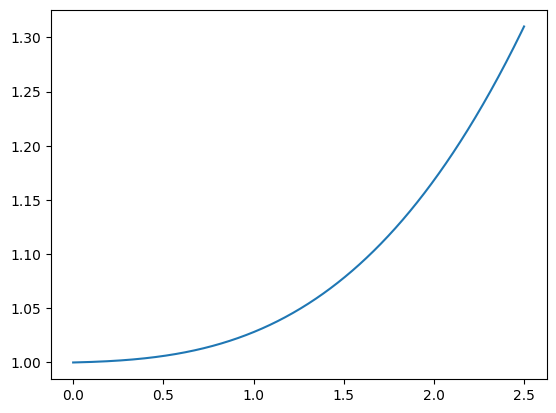

In [126]:
def test(x) :
    return 0.016*x**3 + 0.008*x**2 + 0.004*x + 1

test_t = np.linspace(0.0, 2.5, 1000)
test_x = test(test_t)

plt.plot(test_t, test_x)

In [127]:
@partial(jax.jit, static_argnums=(2,))
def var_model(t, z, component, params):
  return deeponet.apply(params, t, z)[component][0]

@partial(jax.jit, static_argnums=(2,))
def var(t, z, component, params):
  return jax.vmap(var_model, [0, 0, None, None])(t, z, component, params)

@partial(jax.jit, static_argnums=(2,))
def var_t(t, z, component, params):
  return jax.vmap(jax.grad(var_model, 0), [0, 0, None, None])(t, z, component, params)

@jax.jit
def loss(params, tEV, z):

    A_t_loss_w = 1.0
    F_t_loss_w = 1.0
    G_t_loss_w = 1.0
    
    diff_loss_w = 1.0
    E_loss_w = 1.0
    V_loss_w = 1.0

    t_0_val = tEV[:, -3]
    E_0_val = tEV[:, -2]
    V_0_val = tEV[:, -1]

    A_val = var(tEV, z, 0, params)
    F_val = var(tEV, z, 1, params)
    G_val = var(tEV, z, 2, params)
    E_val = var(tEV, z, 3, params)
    
    dA = var_t(tEV, z, 0, params)
    A_t_val = dA[:, 0]
    
    dF = var_t(tEV, z, 1, params)
    F_t_val = dF[:, 0]
    
    dG = var_t(tEV, z, 2, params)
    G_t_val = dG[:, 0]

    dE = var_t(tEV, z, 3, params)
    E_t_val = dE[:, 0]
    E_t_loss = jnp.square(E_t_val)
    E_t_loss = jnp.mean(E_t_loss)
    
    dV = var_t(tEV, z, 4, params)
    V_t_val = dV[:, 0]
    V_t_loss = jnp.square(V_t_val)
    V_t_loss = jnp.mean(V_t_loss)

    dA_dE = dA[:, 1]
    dA_dV = dA[:, 2]

    dF_dE = dF[:, 1]
    dF_dV = dF[:, 2]
    
    dG_dE = dG[:, 1]
    dG_dV = dG[:, 2]

    dE_dE = dE[:, 1]
    E_E_loss = dE_dE - 1.0
    E_E_loss = jnp.square(E_E_loss)
    E_E_loss = jnp.mean(E_E_loss)

    E_val = (0.25)*((A_val**2/l**2) + (F_val**2/k**2) + (2.*(G_val**2)/(k**2 + l**2)))
    E_loss = E_val - E_0_val
    E_loss = jnp.square(E_loss)
    E_loss = jnp.mean(E_loss)
    
    V_val = (0.5)*(A_val**2 + F_val**2 + 2.*(G_val**2))
    V_loss = V_val - V_0_val
    V_loss = jnp.square(V_loss)
    V_loss = jnp.mean(V_loss)
        
    A_t_loss = A_t_val + (1./(k**2) - 1./(k**2 + l**2))*(k * l * F_val * G_val)
    A_t_loss = jnp.square(A_t_loss)
    A_t_loss = jnp.mean(A_t_loss)
    
    F_t_loss = F_t_val - (1./(l**2) - 1./(k**2 + l**2))*(k * l * A_val * G_val)
    F_t_loss = jnp.square(F_t_loss)
    F_t_loss = jnp.mean(F_t_loss)
    
    G_t_loss = G_t_val + (0.5)*(1./(l**2) - 1./(k**2))*(k * l * A_val * F_val)
    G_t_loss = jnp.square(G_t_loss)
    G_t_loss = jnp.mean(G_t_loss)
    
    diff_loss = A_t_loss_w*A_t_loss + F_t_loss_w*F_t_loss + G_t_loss_w*G_t_loss
    
    final_loss = diff_loss_w*diff_loss + E_loss_w*E_loss + V_loss_w*V_loss
    
    return final_loss, 0.0

@jax.jit
def train_step(params, pdes, z):
    tEV = pdes
    
    return jax.value_and_grad(loss, has_aux = True)(params, tEV, z)

@partial(jax.jit, static_argnums=(3,))
def optimize(grads, opt_state, params, optimizer_update):
    updates, opt_state = optimizer_update(grads, opt_state, params)
    params = optax.apply_updates(params, updates)
    return params, opt_state

In [128]:
def train_network(params, des, sensors, epochs=100):

  N = de_points.shape[0]

  nr_batches = 10
  batch_size = len(des)//nr_batches

  print("batch size:", batch_size)

  lr = 1e-3
  optimizer = optax.adam(lr)
  opt_state = optimizer.init(params)

  ds_z = tf.data.Dataset.from_tensor_slices(sensors)
  ds_de = tf.data.Dataset.from_tensor_slices(des)

  ds = tf.data.Dataset.zip((ds_de, ds_z))
  ds = ds.shuffle(N).batch(batch_size)

  epoch_loss = np.zeros(epochs)
  epoch_aux_loss = np.zeros(epochs)

  for i in range(epochs):

    for (des_batch, z_batch) in ds:

      all_losses, grads = train_step(params, des_batch.numpy(), z_batch.numpy())
      loss, aux_loss = all_losses
      params, opt_state = optimize(grads, opt_state, params, optimizer.update)

      epoch_loss[i] += loss
      epoch_aux_loss[i] += aux_loss

    epoch_loss[i] /= batch_size
    epoch_aux_loss[i] /= batch_size
    
    if i % 100  == 0:
      print(f'Loss in epoch {i}: {epoch_loss[i]}')
      print(f'Aux Loss in epoch {i}: {epoch_aux_loss[i]}')

  return params, epoch_loss

In [129]:
deeponet = DeepONet(t0, tfinal, layers=4, units=40)

t_init = jnp.full((10, 3), 1.0)
u_init = jnp.full((10, 3), 1.0)

params = deeponet.init(jax.random.PRNGKey(0), t_init, u_init)

In [130]:
param_count = sum(x.size for x in jax.tree.leaves(params))
print(param_count)

16720


In [131]:
tree_info, shapes, _ = flatten_pytree(params)
params_flat = jnp.load("P_t2.5_2500_5000_ep.npy")
print(params_flat.shape)
params = reconstruct_pytree(tree_info, shapes, params_flat)

(16720,)


batch size: 250
Loss in epoch 0: 0.00023071695402477477
Aux Loss in epoch 0: 0.0
Loss in epoch 100: 3.0185212043328385e-06
Aux Loss in epoch 100: 0.0
Loss in epoch 200: 8.3095852185917e-06
Aux Loss in epoch 200: 0.0
Loss in epoch 300: 2.553616841480716e-06
Aux Loss in epoch 300: 0.0
Loss in epoch 400: 2.2168922701071586e-06
Aux Loss in epoch 400: 0.0
Loss in epoch 500: 2.1366838742145034e-06
Aux Loss in epoch 500: 0.0
Loss in epoch 600: 6.935141714985159e-06
Aux Loss in epoch 600: 0.0
Loss in epoch 700: 1.5945279925953078e-05
Aux Loss in epoch 700: 0.0
Loss in epoch 800: 8.283778687359964e-06
Aux Loss in epoch 800: 0.0
Loss in epoch 900: 2.179372845280105e-06
Aux Loss in epoch 900: 0.0
Loss in epoch 1000: 8.060336592750331e-06
Aux Loss in epoch 1000: 0.0
Loss in epoch 1100: 2.1105340807844892e-06
Aux Loss in epoch 1100: 0.0
Loss in epoch 1200: 1.0782441388752862e-05
Aux Loss in epoch 1200: 0.0
Loss in epoch 1300: 3.794727499942609e-06
Aux Loss in epoch 1300: 0.0
Loss in epoch 1400: 2.1

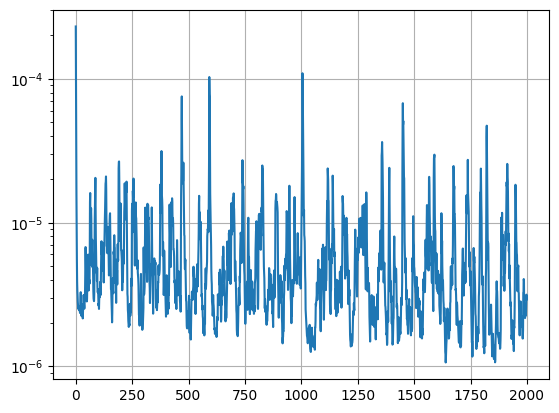

In [132]:
epochs = 2000
params, loss = train_network(params, de_points, zsensors, epochs)

loss_adam = loss
plt.semilogy(loss_adam)
plt.grid()

In [133]:
@jax.jit
def gradD_fun(x, E_0, V_0) :

    factor_E = 1.0
    # factor_V = E_0/V_0
    factor_V = 1.0

    A = x[0]
    F = x[1]
    G = x[2]
    
    dE_dA = A/(2*(l**2))
    dE_dF = F/(2*(k**2))
    dE_dG = G/(k**2 + l**2)

    dV_dA = A
    dV_dF = F
    dV_dG = 2*G
  
    E = (1/4)*((A**2/l**2) + (F**2/k**2) + (2*(G**2)/(k**2 + l**2)))
    V = (1/2)*(A**2 + F**2 + 2*(G**2))

    dD_dA = 2*factor_E*(E-E_0)*dE_dA + 2*factor_V*(V-V_0)*dV_dA
    dD_dF = 2*factor_E*(E-E_0)*dE_dF + 2*factor_V*(V-V_0)*dV_dF
    dD_dG = 2*factor_E*(E-E_0)*dE_dG + 2*factor_V*(V-V_0)*dV_dG

    deriv_D_arr = jnp.array([dD_dA, dD_dF, dD_dG])

    return deriv_D_arr


In [134]:
@jax.jit
def D_fun(x, E_0, V_0) :

    factor_E = 1.0
    # factor_V = E_0/V_0
    factor_V = 1.0
    
    A = x[0]
    F = x[1]
    G = x[2]
        
    E = (1/4)*((A**2/l**2) + (F**2/k**2) + (2.*(G**2)/(k**2 + l**2)))
    V = (1/2)*(A**2 + F**2 + 2*(G**2))

    D = factor_E*((E - E_0)**2) + factor_V*((V - V_0)**2)

    D_arr = jnp.array([D])

    return D_arr

In [135]:
@jax.jit
def find_rec(x):
    
    x = x + jnp.finfo(jnp.float64).eps
    
    return 1/x

In [136]:
@jax.jit
def wolfe_conds(args):

    alpha, curr_x, curr_f, curr_grad, next_x, next_f, next_grad, p, E_0, V_0, iter = args

    c1 = 1e-4

    cond = next_f - curr_f - c1*alpha*(curr_grad.T@p)

    cond_bool = jax.lax.cond(cond[0][0] > 0.0 , lambda x: True, lambda x: False, None)
    final_bool = cond_bool
    
    return final_bool

In [137]:
@jax.jit
def update_alpha(args) :

    alpha, curr_x, curr_f, curr_grad, next_x, next_f, next_grad, p, E_0, V_0, iter = args

    alpha = alpha*0.1
    iter = iter + 1
        
    next_x = curr_x + alpha*p
    next_f = D_fun(next_x, E_0, V_0)
    next_grad = gradD_fun(next_x, E_0, V_0) 
   
    return (alpha, curr_x, curr_f, curr_grad, next_x, next_f, next_grad, p, E_0, V_0, iter)


In [138]:
@jax.jit
def BFGS(x, E_0, V_0) :

    iter_num = 0
    init_iter = 0
    alpha = 1.0
    I_3 = jnp.identity(3, dtype = jnp.float64)
    B_0_inv = jnp.identity(3, dtype = jnp.float64)

    x_0 = x
    x_0 = jnp.reshape(x_0, (-1, 1))

    D_0 = D_fun(x_0, E_0, V_0)
    gradD_0 = gradD_fun(x_0, E_0, V_0)

    p = -(B_0_inv@gradD_0)

    pot_x = x_0 + alpha*p
    pot_D = D_fun(pot_x, E_0, V_0)
    pot_gradD = gradD_fun(pot_x, E_0, V_0)

    init_args = (alpha, x_0, D_0, gradD_0, pot_x, pot_D, pot_gradD, p, E_0, V_0, init_iter)
    
    step, _, _, _, _, _, _, _, _, _, _ = jax.lax.while_loop(wolfe_conds, update_alpha, init_args)

    x_1 = x_0 + step*p

    while iter_num < 5:

        delta_x = x_1 - x_0

        D_1 = D_fun(x_1, E_0, V_0)
        gradD_1 = gradD_fun(x_1, E_0, V_0)

        y = gradD_1 - gradD_0       

        y_T_delta_x = y.T@delta_x
        y_T_delta_x_rec = find_rec(y_T_delta_x)
        
        B_1_inv = ((I_3 - (y_T_delta_x_rec*(delta_x@y.T)))@B_0_inv@(I_3 - (y_T_delta_x_rec*(y@delta_x.T)))) + (y_T_delta_x_rec*(delta_x@delta_x.T))   
        p = -(B_1_inv@gradD_1)
        
        pot_x = x_1 + alpha*p
        pot_D = D_fun(pot_x, E_0, V_0)
        pot_gradD = gradD_fun(pot_x, E_0, V_0) 
                  
        init_args = (alpha, x_1, D_1, gradD_1, pot_x, pot_D, pot_gradD, p, E_0, V_0, init_iter)

        step, _, _, _, _, _, _, _, _, _, _ = jax.lax.while_loop(wolfe_conds, update_alpha, init_args)

        x_temp = x_1 + step*p

        x_0 = x_1
        x_1 = x_temp

        D_0 = D_1
        gradD_0 = gradD_1

        B_0_inv = B_1_inv
        
        iter_num = iter_num + 1

    A = x_1[0]
    F = x_1[1]
    G = x_1[2]

    A = jnp.reshape(A, (-1, ))[0]
    F = jnp.reshape(F, (-1, ))[0]
    G = jnp.reshape(G, (-1, ))[0]


    return x_1

In [139]:
@jax.jit
def find_min_bfgs(x, E_0, V_0) :

    return jax.vmap(BFGS, (0, 0, 0), 0)(x, E_0, V_0)

In [140]:
class ClosestPoint(nn.Module):

    E_0: float
    V_0: float
    
    @nn.compact
    def __call__(self, inputs):
    
        z_min = find_min_bfgs(inputs, self.E_0, self.V_0)
    
        return z_min

In [141]:
class CDeepONet(nn.Module):

  t0: float
  tfinal: float
  layers: int
  units: int

  @nn.compact
  def __call__(self, t, u):

    if u.ndim == 1:
      u = jnp.reshape(u, (1,-1))
      
    if t.ndim == 1:
      t = jnp.reshape(t, (1,-1))
        
    t_0 = t[:, :1]
    E_0 = t[:, 1:2]
    V_0 = t[:, 2:3]
      
    t_0 = jnp.reshape(t_0, (-1,1))
    t_0_norm = Normalize(self.t0, self.tfinal)(t_0)

    b = jnp.column_stack((t_0_norm, E_0, V_0))
      
    A_0 = u[:,:1]
    F_0 = u[:,1:2]
    G_0 = u[:,2:3]

    trunk_net = MLP(self.layers, self.units)(b)
    branch_net = MLP(self.layers, self.units)(u)

    A_tr = trunk_net[:,:self.units]
    F_tr = trunk_net[:,self.units:2*self.units]
    G_tr = trunk_net[:,2*self.units:]

    A_br = branch_net[:,:self.units]
    F_br = branch_net[:,self.units:2*self.units]
    G_br = branch_net[:,2*self.units:]

    A = CombineBranches()(A_tr, A_br)
    F = CombineBranches()(F_tr, F_br)
    G = CombineBranches()(G_tr, G_br)

    A = HardConstraint(self.t0, self.tfinal, A_0)([t_0, A])
    F = HardConstraint(self.t0, self.tfinal, F_0)([t_0, F])
    G = HardConstraint(self.t0, self.tfinal, G_0)([t_0, G])

    z = jnp.column_stack([A, F, G])
    z = ClosestPoint(E_0, V_0)(z)   

    A = z[:, :1]
    F = z[:, 1:2]
    G = z[:, 2:3]
      
    A = jnp.reshape(A, (-1,))
    F = jnp.reshape(F, (-1,))
    G = jnp.reshape(G, (-1,))
    E = (0.25)*((A**2/l**2) + (F**2/k**2) + (2.*(G**2)/(k**2 + l**2)))
    V = (0.5)*(A**2 + F**2 + 2.*(G**2))

    return A, F, G, E, V

In [142]:
@partial(jax.jit, static_argnums=(2,))
def Cvar_model(t, z, component, params):
  return Cdeeponet.apply(params, t, z)[component][0]

@partial(jax.jit, static_argnums=(2,))
def Cvar(t, z, component, params):
  return jax.vmap(Cvar_model, [0, 0, None, None])(t, z, component, params)

@partial(jax.jit, static_argnums=(2,))
def Cvar_t(t, z, component, params):
  return jax.vmap(jax.grad(Cvar_model, 0), [0, 0, None, None])(t, z, component, params)

@jax.jit
def Closs(params, tEV, z):

    A_t_loss_w = 1.0
    F_t_loss_w = 1.0
    G_t_loss_w = 1.0
    
    diff_loss_w = 1.0
    E_loss_w = 0.0
    V_loss_w = 0.0
    
    E_0_val = tEV[:, -2]
    V_0_val = tEV[:, -1]
    
    A_val = Cvar(tEV, z, 0, params)
    F_val = Cvar(tEV, z, 1, params)
    G_val = Cvar(tEV, z, 2, params)
    
    dA = Cvar_t(tEV, z, 0, params)
    A_t_val = dA[:, 0]
    
    dF = Cvar_t(tEV, z, 1, params)
    F_t_val = dF[:, 0]
    
    dG = Cvar_t(tEV, z, 2, params)
    G_t_val = dG[:, 0]

    dE = Cvar_t(tEV, z, 3, params)
    E_t_val = dE[:, 0]
    E_t_loss = jnp.square(E_t_val)
    E_t_loss = jnp.mean(E_t_loss)

    dV = Cvar_t(tEV, z, 4, params)
    V_t_val = dV[:, 0]
    V_t_loss = jnp.square(V_t_val)
    V_t_loss = jnp.mean(V_t_loss)    

    dA_dE = dA[:, 1]
    dA_dV = dA[:, 2]

    dF_dE = dF[:, 1]
    dF_dV = dF[:, 2]
    
    dG_dE = dG[:, 1]
    dG_dV = dG[:, 2]


    dE_dE = dE[:, 1]
    E_E_loss = dE_dE - 1.0
    E_E_loss = jnp.square(E_E_loss)
    E_E_loss = jnp.mean(E_E_loss)

    
    E_val = (0.25)*((A_val**2/l**2) + (F_val**2/k**2) + (2.*(G_val**2)/(k**2 + l**2)))
    E_loss = E_val - E_0_val
    E_loss = jnp.square(E_loss)
    E_loss = jnp.mean(E_loss)
    
    V_val = (0.5)*(A_val**2 + F_val**2 + 2.*(G_val**2))
    V_loss = V_val - V_0_val
    V_loss = jnp.square(V_loss)
    V_loss = jnp.mean(V_loss)
        
    A_t_loss = A_t_val + (1./(k**2) - 1./(k**2 + l**2))*(k * l * F_val * G_val)
    A_t_loss = jnp.square(A_t_loss)
    A_t_loss = jnp.mean(A_t_loss)
    
    F_t_loss = F_t_val - (1./(l**2) - 1./(k**2 + l**2))*(k * l * A_val * G_val)
    F_t_loss = jnp.square(F_t_loss)
    F_t_loss = jnp.mean(F_t_loss)
    
    G_t_loss = G_t_val + (0.5)*(1./(l**2) - 1./(k**2))*(k * l * A_val * F_val)
    G_t_loss = jnp.square(G_t_loss)
    G_t_loss = jnp.mean(G_t_loss)
    
    diff_loss = A_t_loss_w*A_t_loss + F_t_loss_w*F_t_loss + G_t_loss_w*G_t_loss
    
    final_loss = diff_loss_w*diff_loss + E_loss_w*E_loss + V_loss_w*V_loss
    
    return final_loss, E_t_loss + V_t_loss

@jax.jit
def Ctrain_step(params, pdes, z):
    tEV = pdes
    
    return jax.value_and_grad(Closs, has_aux = True)(params, tEV, z)


@partial(jax.jit, static_argnums=(3,))
def Coptimize(grads, opt_state, params, optimizer_update):
    updates, opt_state = optimizer_update(grads, opt_state, params)
    params = optax.apply_updates(params, updates)
    return params, opt_state

In [143]:
def Ctrain_network(params, des, sensors, epochs=100):

    N = de_points.shape[0]
    
    nr_batches = 10
    batch_size = len(des)//nr_batches
    
    print("batch size:", batch_size)
    
    lr = 1e-5
    optimizer = optax.adagrad(lr)
    opt_state = optimizer.init(params)
    
    ds_z = tf.data.Dataset.from_tensor_slices(sensors)
    ds_de = tf.data.Dataset.from_tensor_slices(des)
    
    ds = tf.data.Dataset.zip((ds_de, ds_z))
    ds = ds.shuffle(N).batch(batch_size)
    
    epoch_loss = np.zeros(epochs)
    epoch_aux_loss = np.zeros(epochs)
    
    for i in range(epochs):

        print(i)

        batch_no = 0
    
        for (des_batch, z_batch) in ds:
    
            losses, grads = Ctrain_step(params, des_batch.numpy(), z_batch.numpy())
            loss, aux_loss = losses
            
            params, opt_state = Coptimize(grads, opt_state, params, optimizer.update)
            
            epoch_loss[i] += loss
            epoch_aux_loss[i] += aux_loss
            

            batch_no = batch_no + 1

        epoch_loss[i] /= batch_size
        epoch_aux_loss[i] /= batch_size

        if i % 10  == 0:
            print(f'Loss in epoch {i}: {epoch_loss[i]}')
            print(f'Aux Loss in epoch {i}: {epoch_aux_loss[i]}')

    return params, epoch_loss

In [144]:
Cdeeponet = CDeepONet(t0, tfinal, layers=4, units=40)

t_init = jnp.full((10, 3), 1.0, dtype = jnp.float64)
u_init = jnp.full((10, 3), 1.0, dtype = jnp.float64 )

Cparams = Cdeeponet.init(jax.random.PRNGKey(0), t_init, u_init)

In [145]:
Cparam_count = sum(x.size for x in jax.tree.leaves(Cparams))
print(Cparam_count)

16720


In [146]:
Cparams = copy.deepcopy(params)

In [147]:
@jax.jit
def loss_fun(params, t, z):

    final_loss, imp_loss = Closs(params, t, z)
    
    return final_loss


@jax.jit
def loss_grad_fun(params, t, z):
    
      return jax.grad(loss_fun, has_aux = False)(params, t, z)


@jax.jit
def loss_fun_aux(params, t, z):

    final_loss, aux_loss = Closs(params, t, z)
    
    return final_loss, aux_loss


In [148]:
@jax.jit
def computeH0(y, s):

  numerator = y.T@s
  denominator = y.T@y
  gamma = jnp.where(denominator > 0, numerator/denominator, 1.0)
  return gamma*jnp.eye(s.shape[0])

In [149]:
@jax.jit
def lineSearchBacktracking(x, p, g, t, z):       

    c1 = 1e-3
    gamma = 0.5
    max_iter = 15
  
    alpha_init = 1.0
    iter_init = 0
    
    args_init = alpha_init, iter_init

    def conditions(args) :

        alpha, iter = args
        
        xn = x + alpha*p

        params = reconstruct_pytree(tree_info, shapes, x)
        paramsn = reconstruct_pytree(tree_info, shapes, xn)
        fx = loss_fun(params, t, z)
        fxn = loss_fun(paramsn, t, z)

        cond1 = jax.lax.cond(fxn >= fx + c1*alpha*g.T@p , lambda x: True, lambda x: False, None)
        # cond2 = jax.lax.cond(iter < max_iter , lambda x: True, lambda x: False, None)
        # cond = jnp.logical_and(cond1, cond2)
        cond = cond1

        return cond

    def update_step(args) :

        alpha, iter = args
        
        iter = iter + 1
        alpha = alpha*gamma

        return (alpha, iter)

    
    alpha, _ = jax.lax.while_loop(conditions, update_step, args_init)   
    
    return alpha

In [150]:
@jax.jit
def body_fun_1(i, args) :

    rho, alpha, g, y, s, m = args

    i = m - i - 1
    
    rho.at[i].set(1.0 / (y[i].T @ s[i]))
    alpha.at[i].set(rho[i] * s[i].T @ g)
    g -= alpha[i] * y[i]

    return rho, alpha, g, y, s, m


@jax.jit
def body_fun_2(i, args) :

    rho, alpha, g, Hg, y, s = args
    
    beta = rho[i] * y[i].T @ Hg
    Hg += (alpha[i] - beta) * s[i]  

    return rho, alpha, g, Hg, y, s
    

In [151]:
def lbfgs(params, pdes, z, max_iters_val):

    max_iters = max_iters_val
    max_m = 5
    
    s = jnp.zeros((max_m, Cparam_count), dtype = jnp.float64)
    y = jnp.zeros((max_m, Cparam_count), dtype = jnp.float64)
    
    t = pdes
    
    losses = [loss_fun(params, t, z)]
    tree_info, shapes, x = flatten_pytree(params)
    
    g = loss_grad_fun(params,t , z)
    _, _, g = flatten_pytree(g)
    g = jnp.float64(g)

    
    for k in range(max_iters):

        m = k if k < max_m else max_m
        Hg = g if m == 0 else computeH0(y[m-1], s[m-1]) @ g

        if m > 0:

            alpha = jnp.zeros(m, dtype = jnp.float64)
            rho = jnp.zeros(m, dtype = jnp.float64)

            args_1 = (rho, alpha, g, y, s, m)
            rho, alpha, g, y, s, _ = jax.lax.fori_loop(0, m, body_fun_1, args_1)

            args_2 = (rho, alpha, g, Hg, y, s)
            rho, alpha, g, Hg, y, s = jax.lax.fori_loop(0, m, body_fun_2, args_2)

        Hg = -Hg

        eta = lineSearchBacktracking(x, Hg, g, t, z)
        xn = x + eta*Hg

        s.at[k, :].set(xn - x)
        paramsn = reconstruct_pytree(tree_info, shapes, xn)
        gn = loss_grad_fun(paramsn, t, z)
        _, _, gn = flatten_pytree(gn)

        y.at[k, :].set(gn - g)

        x = xn
        g = gn

        losses.append(loss_fun(paramsn, t, z))
     
        # if k % 10 == 0:
            
        #     print(f'Iteration: {k}, Loss: {losses[-1]}')

    _, aux_loss = loss_fun_aux(paramsn, t, z)

    return paramsn, (losses, aux_loss)

In [152]:
def ctrain_network_lbfgs(params, des, zsensor, epochs=100):

    N = de_points.shape[0]
    
    nr_batches = 10
    batch_size = len(des)//nr_batches
    
    ds_z = tf.data.Dataset.from_tensor_slices(zsensor)
    ds_de = tf.data.Dataset.from_tensor_slices(des)
    
    ds = tf.data.Dataset.zip((ds_de, ds_z))
    ds = ds.shuffle(N).batch(batch_size)
    
    epoch_loss = np.zeros(epochs)

    for i in range(epochs):
      
        print(i)
      
        for (des_batch, z_batch) in ds:
        
          params, losses = lbfgs(params, des_batch.numpy(), z_batch.numpy(), 5)
          loss, aux_loss = losses
          epoch_loss[i] += loss[-1]

        epoch_loss[i] /= batch_size

        if i % 1 == 0:
            print(f'Loss in epoch {i}: {epoch_loss[i]}')
            print(f'Aux Loss in epoch {i}: {aux_loss}')

    return params, epoch_loss

In [153]:
print(de_points.shape, zsensors.shape)

(2500, 3) (2500, 3)


In [154]:
tree_info, shapes, _ = flatten_pytree(Cparams)
Cparams_flat = jnp.load("C_t2.5_2500_2000_ep.npy")
print(Cparams_flat.shape)
Cparams = reconstruct_pytree(tree_info, shapes, Cparams_flat)

(16720,)


In [155]:
# epochs = 20
# Cparams, loss_lbfgs = ctrain_network_lbfgs(Cparams, de_points, zsensors, epochs)

In [156]:
# epochs = 250
# Cparams, loss_lbfgs = Ctrain_network(Cparams, de_points, zsensors, epochs)

In [157]:
# plt.semilogy(loss_lbfgs)
# plt.grid()
# total_loss = np.concatenate((loss_adam, loss_lbfgs))
# plt.semilogy(total_loss)
# plt.grid()

In [158]:
def set_vals(list) :

    A_val = np.array(list[0], dtype = np.float64)
    F_val = np.array(list[1], dtype = np.float64)
    G_val = np.array(list[2], dtype = np.float64)
    E_val = (1/4)*((A_val**2/l**2) + (F_val**2/k**2) + (2*(G_val**2)/(k**2 + l**2)))
    V_val = (1/2)*(A_val**2 + F_val**2 + 2*(G_val**2))

    return A_val, F_val, G_val, E_val, V_val

In [159]:
def init_preds(n) :

    return np.zeros(n), np.zeros(n), np.zeros(n), np.zeros(n), np.zeros(n)

In [160]:
def prep_train(t_data, A, F, G, E, V, model, params, n) :

    E_data = np.repeat(np.expand_dims(E, axis=0), n, axis=0)
    V_data = np.repeat(np.expand_dims(V, axis=0), n, axis=0)
    tEV_data = np.column_stack([t_data, E_data, V_data])
   
    AFG_data = np.column_stack([A, F, G])
    AFG_data = np.reshape(AFG_data, (-1,))
    AFG_data = np.repeat(np.expand_dims(AFG_data, axis=0), n, axis=0)

    A = jax.vmap(model, [0, 0, None, None])(tEV_data, AFG_data, 0, params)
    F = jax.vmap(model, [0, 0, None, None])(tEV_data, AFG_data, 1, params)
    G = jax.vmap(model, [0, 0, None, None])(tEV_data, AFG_data, 2, params)
    E = (1/4)*((A**2/l**2) + (F**2/k**2) + (2*(G**2)/(k**2 + l**2)))
    V = (1/2)*(A**2 + F**2 + 2*(G**2))   

    return A, F, G, E, V, tEV_data, AFG_data

In [161]:
#Empty

0.005 40000 80


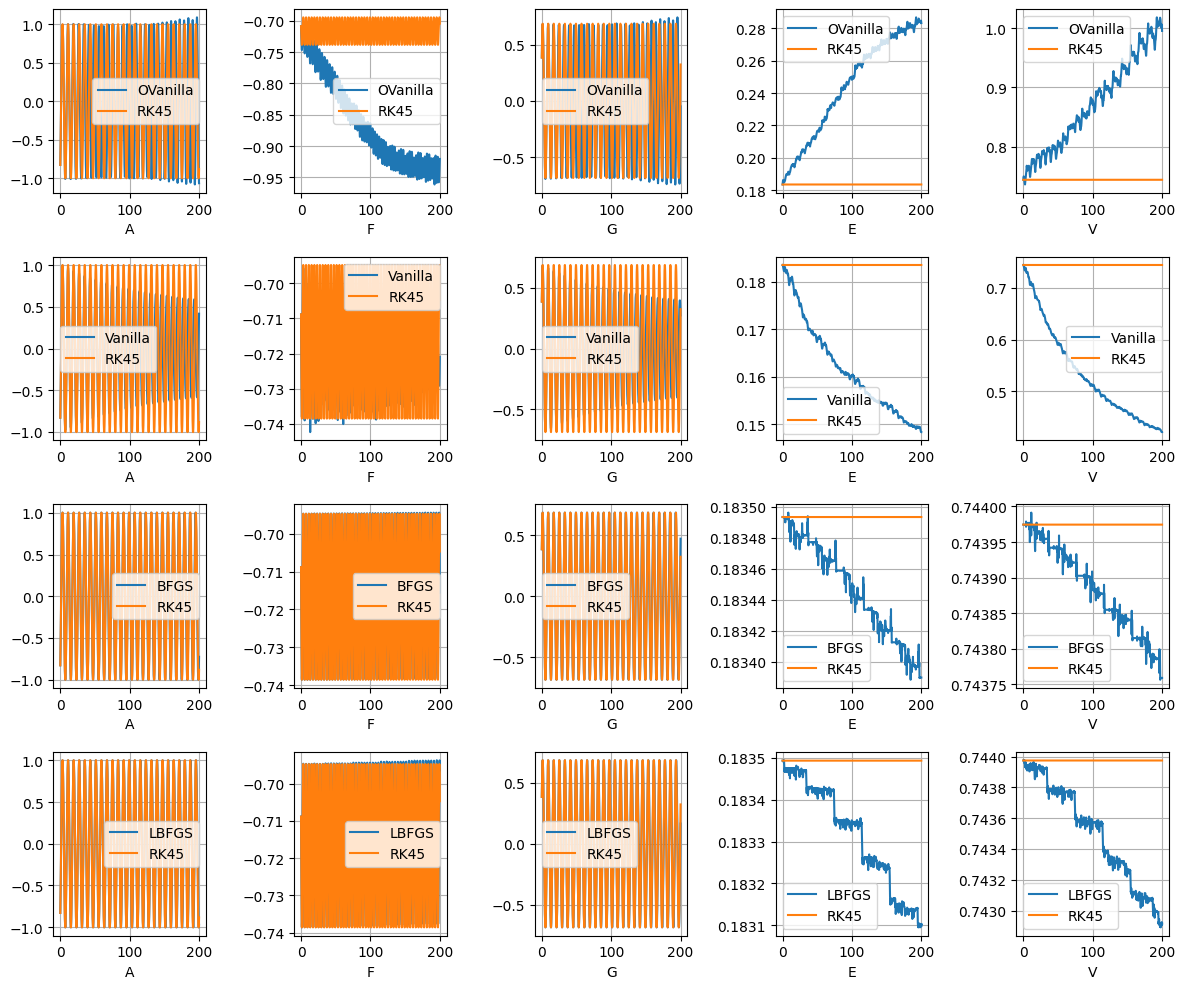

In [162]:
n = 500

t_start = 0.0
t_end = 200.0

n_ts = int(n*(t_end/tfinal))

t_step = t_end/n_ts

num_cycles = math.ceil(n_ts/n)
print(t_step, n_ts, num_cycles)

t_ts = np.linspace(t_start, t_end, n_ts)

A_init = np.random.uniform(-1.0, 1.0, size=(1,))
F_init = np.random.uniform(-1.0, 1.0, size=(1,))
G_init = np.random.uniform(-1.0, 1.0, size=(1,))
E_init = (1/4)*((A_init**2/l**2) + (F_init**2/k**2) + (2*(G_init**2)/(k**2 + l**2)))
V_init = (1/2)*(A_init**2 + F_init**2 + 2*(G_init**2))

# A_init, F_init, G_init, E_init, V_init = set_vals([[-0.40824746], [-0.21609818], [-0.72853105]])

data_rk = np.column_stack([A_init, F_init, G_init])
data_rk = np.reshape(data_rk, (-1,))
t_rk = t_ts

sol_rk = odeint(Lorenz1960, data_rk, t_rk, rtol = 1e-13, atol = 1e-13)
A_rk, F_rk, G_rk = sol_rk[:,0], sol_rk[:,1], sol_rk[:,2]
E_rk = (1/4)*((A_rk**2/l**2) + (F_rk**2/k**2) + (2*(G_rk**2)/(k**2 + l**2)))
V_rk = (1/2)*(A_rk**2 + F_rk**2 + 2*(G_rk**2))

A_pred_ovan, F_pred_ovan, G_pred_ovan, E_pred_ovan, V_pred_ovan = init_preds(n_ts)

A_pred_van, F_pred_van, G_pred_van, E_pred_van, V_pred_van = init_preds(n_ts)

A_pred_bfgs, F_pred_bfgs, G_pred_bfgs, E_pred_bfgs, V_pred_bfgs = init_preds(n_ts)

A_pred_lbfgs, F_pred_lbfgs, G_pred_lbfgs, E_pred_lbfgs, V_pred_lbfgs = init_preds(n_ts)

A_data_ovan, A_data_van, A_data_bfgs, A_data_lbfgs = A_init, A_init, A_init, A_init
F_data_ovan, F_data_van, F_data_bfgs, F_data_lbfgs = F_init, F_init, F_init, F_init
G_data_ovan, G_data_van, G_data_bfgs, G_data_lbfgs = G_init, G_init, G_init, G_init
E_data_ovan, E_data_van, E_data_bfgs, E_data_lbfgs = E_init, E_init, E_init, E_init
V_data_ovan, V_data_van, V_data_bfgs, V_data_lbfgs = V_init, V_init, V_init, V_init


t_data = np.linspace(t0, tfinal, n)
t_data_sub = np.linspace(t0 + t_step, tfinal, n)

for i in range(num_cycles) :

    if i != 0 :
        t_data = t_data_sub

    A_ovan, F_ovan, G_ovan, E_ovan, V_ovan, _, _ = prep_train(t_data, 
                                                   A_data_ovan, F_data_ovan, G_data_ovan, E_data_ovan, V_data_ovan, 
                                                   Vvar_model, Vparams, n)    

    A_van, F_van, G_van, E_van, V_van, _, _ = prep_train(t_data, 
                                                   A_data_van, F_data_van, G_data_van, E_data_van, V_data_van, 
                                                   var_model, params, n)

    A_bfgs, F_bfgs, G_bfgs, E_bfgs, V_bfgs, _, _ = prep_train(t_data, 
                                                   A_data_bfgs, F_data_bfgs, G_data_bfgs, E_data_bfgs, V_data_bfgs, 
                                                   Cvar_model, params, n)  
    
    A_lbfgs, F_lbfgs, G_lbfgs, E_lbfgs, V_lbfgs, _, _ = prep_train(t_data, 
                                                   A_data_lbfgs, F_data_lbfgs, G_data_lbfgs, E_data_lbfgs, V_data_lbfgs, 
                                                   Cvar_model, Cparams, n)    

    A_pred_ovan[i*n:(i+1)*n] = A_ovan
    F_pred_ovan[i*n:(i+1)*n] = F_ovan
    G_pred_ovan[i*n:(i+1)*n] = G_ovan
    E_pred_ovan[i*n:(i+1)*n] = E_ovan
    V_pred_ovan[i*n:(i+1)*n] = V_ovan

    A_pred_van[i*n:(i+1)*n] = A_van
    F_pred_van[i*n:(i+1)*n] = F_van
    G_pred_van[i*n:(i+1)*n] = G_van
    E_pred_van[i*n:(i+1)*n] = E_van
    V_pred_van[i*n:(i+1)*n] = V_van
    
    A_pred_bfgs[i*n:(i+1)*n] = A_bfgs
    F_pred_bfgs[i*n:(i+1)*n] = F_bfgs
    G_pred_bfgs[i*n:(i+1)*n] = G_bfgs
    E_pred_bfgs[i*n:(i+1)*n] = E_bfgs
    V_pred_bfgs[i*n:(i+1)*n] = V_bfgs
    
    A_pred_lbfgs[i*n:(i+1)*n] = A_lbfgs
    F_pred_lbfgs[i*n:(i+1)*n] = F_lbfgs
    G_pred_lbfgs[i*n:(i+1)*n] = G_lbfgs
    E_pred_lbfgs[i*n:(i+1)*n] = E_lbfgs
    V_pred_lbfgs[i*n:(i+1)*n] = V_lbfgs

    A_data_ovan = A_pred_ovan[(i+1)*n - 1]
    F_data_ovan = F_pred_ovan[(i+1)*n - 1]
    G_data_ovan = G_pred_ovan[(i+1)*n - 1]
    E_data_ovan = E_pred_ovan[(i+1)*n - 1]
    V_data_ovan = V_pred_ovan[(i+1)*n - 1]
 
    A_data_van = A_pred_van[(i+1)*n - 1]
    F_data_van = F_pred_van[(i+1)*n - 1]
    G_data_van = G_pred_van[(i+1)*n - 1]
    E_data_van = E_pred_van[(i+1)*n - 1]
    V_data_van = V_pred_van[(i+1)*n - 1]

    A_data_bfgs = A_pred_bfgs[(i+1)*n - 1]
    F_data_bfgs = F_pred_bfgs[(i+1)*n - 1]
    G_data_bfgs = G_pred_bfgs[(i+1)*n - 1]
    E_data_bfgs = E_pred_bfgs[(i+1)*n - 1]
    V_data_bfgs = V_pred_bfgs[(i+1)*n - 1]
    
    A_data_lbfgs = A_pred_lbfgs[(i+1)*n - 1]
    F_data_lbfgs = F_pred_lbfgs[(i+1)*n - 1]
    G_data_lbfgs = G_pred_lbfgs[(i+1)*n - 1]
    E_data_lbfgs = E_pred_lbfgs[(i+1)*n - 1]
    V_data_lbfgs = V_pred_lbfgs[(i+1)*n - 1]


fig = plt.figure(figsize=(12, 10))

plt.subplot(4, 5, 1)
plt.tight_layout()
plt.plot(t_ts, A_pred_ovan)
plt.plot(t_ts, A_rk)
plt.xlabel("A")
plt.grid()
plt.legend(['OVanilla','RK45'])

plt.subplot(4, 5, 2)
plt.tight_layout()
plt.plot(t_ts, F_pred_ovan)
plt.plot(t_ts, F_rk)
plt.xlabel("F")
plt.grid()
plt.legend(['OVanilla','RK45'])

plt.subplot(4, 5, 3)
plt.tight_layout()
plt.plot(t_ts, G_pred_ovan)
plt.plot(t_ts, G_rk)
plt.xlabel("G")
plt.grid()
plt.legend(['OVanilla','RK45'])

plt.subplot(4, 5, 4)
plt.tight_layout()
plt.plot(t_ts, E_pred_ovan)
plt.plot(t_ts, E_rk)
plt.xlabel("E")
plt.grid()
plt.legend(['OVanilla','RK45'])

plt.subplot(4, 5, 5)
plt.tight_layout()
plt.plot(t_ts, V_pred_ovan)
plt.plot(t_ts, V_rk)
plt.xlabel("V")
plt.grid()
plt.legend(['OVanilla','RK45'])

plt.subplot(4, 5, 6)
plt.tight_layout()
plt.plot(t_ts, A_pred_van)
plt.plot(t_ts, A_rk)
plt.xlabel("A")
plt.grid()
plt.legend(['Vanilla','RK45'])

plt.subplot(4, 5, 7)
plt.tight_layout()
plt.plot(t_ts, F_pred_van)
plt.plot(t_ts, F_rk)
plt.xlabel("F")
plt.grid()
plt.legend(['Vanilla','RK45'])

plt.subplot(4, 5, 8)
plt.tight_layout()
plt.plot(t_ts, G_pred_van)
plt.plot(t_ts, G_rk)
plt.xlabel("G")
plt.grid()
plt.legend(['Vanilla','RK45'])

plt.subplot(4, 5, 9)
plt.tight_layout()
plt.plot(t_ts, E_pred_van)
plt.plot(t_ts, E_rk)
plt.xlabel("E")
plt.grid()
plt.legend(['Vanilla','RK45'])

plt.subplot(4, 5, 10)
plt.tight_layout()
plt.plot(t_ts, V_pred_van)
plt.plot(t_ts, V_rk)
plt.xlabel("V")
plt.grid()
plt.legend(['Vanilla','RK45'])

plt.subplot(4, 5, 11)
plt.tight_layout()
plt.plot(t_ts, A_pred_bfgs)
plt.plot(t_ts, A_rk)
plt.xlabel("A")
plt.grid()
plt.legend(['BFGS','RK45'])

plt.subplot(4, 5, 12)
plt.tight_layout()
plt.plot(t_ts, F_pred_bfgs)
plt.plot(t_ts, F_rk)
plt.xlabel("F")
plt.grid()
plt.legend(['BFGS','RK45'])

plt.subplot(4, 5, 13)
plt.tight_layout()
plt.plot(t_ts, G_pred_bfgs)
plt.plot(t_ts, G_rk)
plt.xlabel("G")
plt.grid()
plt.legend(['BFGS','RK45'])

plt.subplot(4, 5, 14)
plt.tight_layout()
plt.plot(t_ts, E_pred_bfgs)
plt.plot(t_ts, E_rk)
plt.xlabel("E")
plt.grid()
plt.legend(['BFGS','RK45'])


plt.subplot(4, 5, 15)
plt.tight_layout()
plt.plot(t_ts, V_pred_bfgs)
plt.plot(t_ts, V_rk)
plt.xlabel("V")
plt.grid()
plt.legend(['BFGS','RK45'])

plt.subplot(4, 5, 16)
plt.tight_layout()
plt.plot(t_ts, A_pred_lbfgs)
plt.plot(t_ts, A_rk)
plt.xlabel("A")
plt.grid()
plt.legend(['LBFGS','RK45'])

plt.subplot(4, 5, 17)
plt.tight_layout()
plt.plot(t_ts, F_pred_lbfgs)
plt.plot(t_ts, F_rk)
plt.xlabel("F")
plt.grid()
plt.legend(['LBFGS','RK45'])

plt.subplot(4, 5, 18)
plt.tight_layout()
plt.plot(t_ts, G_pred_lbfgs)
plt.plot(t_ts, G_rk)
plt.xlabel("G")
plt.grid()
plt.legend(['LBFGS','RK45'])

plt.subplot(4, 5, 19)
plt.tight_layout()
plt.plot(t_ts, E_pred_lbfgs)
plt.plot(t_ts, E_rk)
plt.xlabel("E")
plt.grid()
plt.legend(['LBFGS','RK45'])

plt.subplot(4, 5, 20)
plt.tight_layout()
plt.plot(t_ts, V_pred_lbfgs)
plt.plot(t_ts, V_rk)
plt.xlabel("V")
plt.grid()
plt.legend(['LBFGS','RK45'])

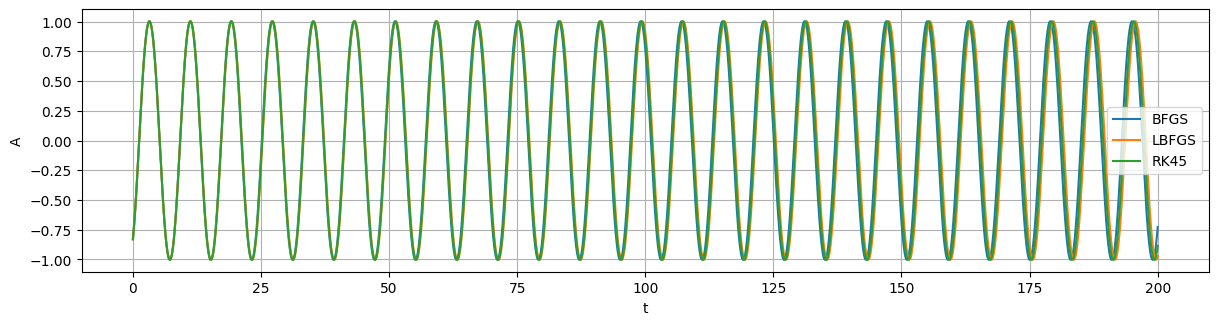

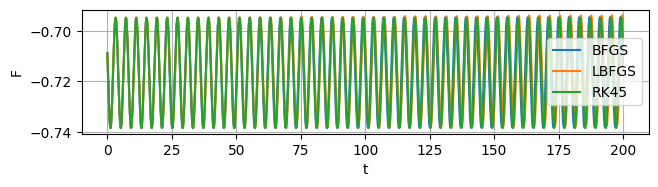

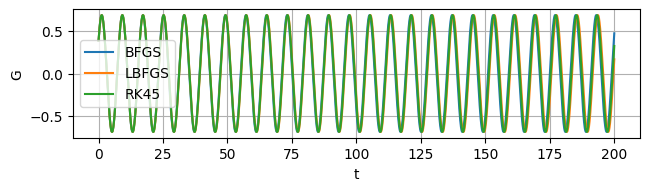

In [163]:
fig = plt.figure(figsize=(12, 9))

plt.subplot(3, 1, 1)
plt.tight_layout()
#plt.plot(t_ts, A_pred_ovan, label = 'OVanilla')
#plt.plot(t_ts, A_pred_van, label = 'Vanilla')
plt.plot(t_ts, A_pred_bfgs, label = 'BFGS')
plt.plot(t_ts, A_pred_lbfgs, label = 'LBFGS')
plt.plot(t_ts, A_rk, label = 'RK45')
plt.xlabel("t")
plt.ylabel("A")
plt.grid()
plt.legend()
plt.show()

plt.subplot(3, 1, 2)
plt.tight_layout()
#plt.plot(t_ts, F_pred_ovan, label = 'OVanilla')
#plt.plot(t_ts, F_pred_van, label = 'Vanilla')
plt.plot(t_ts, F_pred_bfgs, label = 'BFGS')
plt.plot(t_ts, F_pred_lbfgs, label = 'LBFGS')
plt.plot(t_ts, F_rk, label = 'RK45')
plt.xlabel("t")
plt.ylabel("F")
plt.grid()
plt.legend()
plt.show()

plt.subplot(3, 1, 3)
plt.tight_layout()
#plt.plot(t_ts, G_pred_ovan, label = 'OVanilla')
#plt.plot(t_ts, G_pred_van, label = 'Vanilla')
plt.plot(t_ts, G_pred_bfgs, label = 'BFGS')
plt.plot(t_ts, G_pred_lbfgs, label = 'LBFGS')
plt.plot(t_ts, G_rk, label = 'RK45')
plt.xlabel("t")
plt.ylabel("G")
plt.grid()
plt.legend()
plt.show()

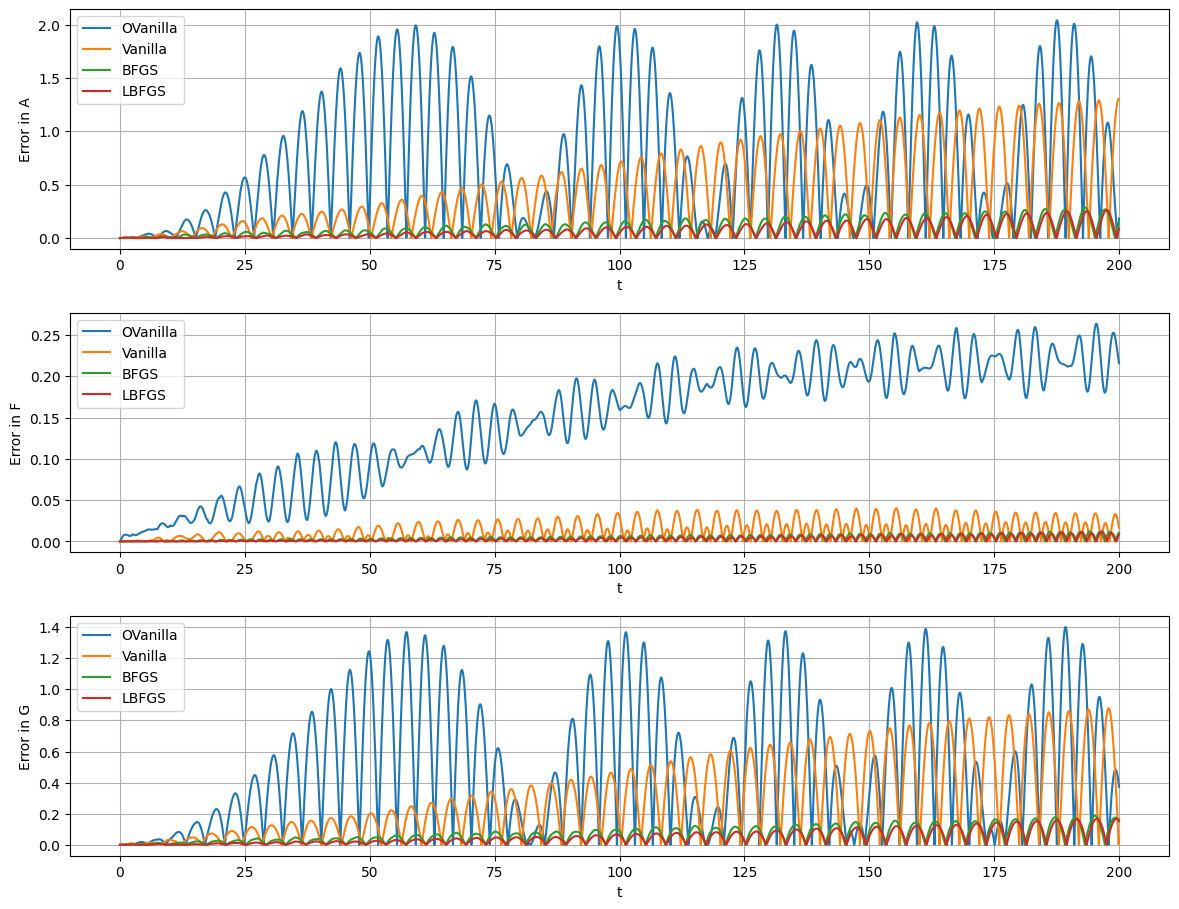

In [164]:
fig = plt.figure(figsize=(12, 9))

plt.subplot(3, 1, 1)
plt.tight_layout()
plt.plot(t_ts, abs(A_pred_ovan - A_rk), label = 'OVanilla')
plt.plot(t_ts, abs(A_pred_van - A_rk), label = 'Vanilla')
plt.plot(t_ts, abs(A_pred_bfgs - A_rk), label = 'BFGS')
plt.plot(t_ts, abs(A_pred_lbfgs - A_rk), label = 'LBFGS')
plt.xlabel("t")
plt.ylabel("Error in A")
plt.grid()
plt.legend()

plt.subplot(3, 1, 2)
plt.tight_layout()
plt.plot(t_ts, abs(F_pred_ovan - F_rk), label = 'OVanilla')
plt.plot(t_ts, abs(F_pred_van - F_rk), label = 'Vanilla')
plt.plot(t_ts, abs(F_pred_bfgs - F_rk), label = 'BFGS')
plt.plot(t_ts, abs(F_pred_lbfgs - F_rk), label = 'LBFGS')
plt.xlabel("t")
plt.ylabel("Error in F")
plt.grid()
plt.legend()

plt.subplot(3, 1, 3)
plt.tight_layout()
plt.plot(t_ts, abs(G_pred_ovan - G_rk), label = 'OVanilla')
plt.plot(t_ts, abs(G_pred_van - G_rk), label = 'Vanilla')
plt.plot(t_ts, abs(G_pred_bfgs - G_rk), label = 'BFGS')
plt.plot(t_ts, abs(G_pred_lbfgs - G_rk), label = 'LBFGS')
plt.xlabel("t")
plt.ylabel("Error in G")
plt.grid()
plt.legend()

Text(0.5, 0, 'G')

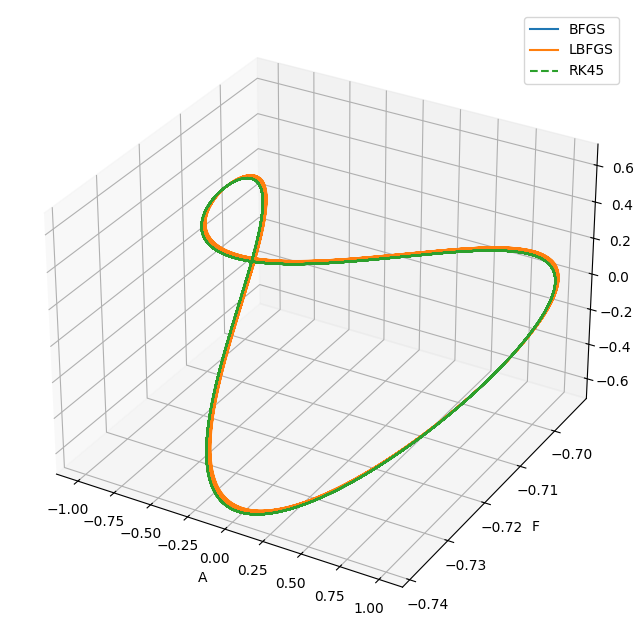

In [165]:
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(projection='3d')
#ax.plot(A_pred_ovan, F_pred_ovan, G_pred_ovan, label='OVanilla')
#ax.plot(A_pred_van, F_pred_van, G_pred_van, label='Vanilla')
ax.plot(A_pred_bfgs, F_pred_bfgs, G_pred_bfgs, label='BFGS')
ax.plot(A_pred_lbfgs, F_pred_lbfgs, G_pred_lbfgs, label='LBFGS')
ax.plot(A_rk, F_rk, G_rk, linestyle='--', label='RK45')
ax.legend()
ax.set_xlabel('A')
ax.set_ylabel('F')
ax.set_zlabel('G')

In [166]:
# tree_info, shapes, Vparams_flat = flatten_pytree(Vparams)
# jnp.save("V_t2.5_2500_5000_ep", Vparams_flat)

# tree_info, shapes, params_flat = flatten_pytree(params)
# jnp.save("P_t2.5_2500_5000_ep_norm", params_flat)

# tree_info, shapes, Cparams_flat = flatten_pytree(Cparams)
# jnp.save("C_t2.5_2500_20_ep_norm", Cparams_flat)

In [167]:
# print(A_init, F_init, G_init, E_init, V_init)
# [-0.40824746] [-0.21609818] [-0.72853105] BFGS better

# [0.15362419] [0.53170375] [0.81017482] LBFGS better
# [0.94742966] [-0.80330454] [0.46645207] !!

# [-0.24342532] [0.31170817] [-0.85430722] All bad

In [168]:
def compare_methods(num_trials, t_end_val) :

    n = 500
    trials_num = [i+1 for i in range(num_trials)]
    
    t_start = 0.0
    t_end = t_end_val
    
    n_ts = int(n*(t_end/tfinal))
    
    t_step = t_end/n_ts
    
    num_cycles = math.ceil(n_ts/n)
    
    t_ts = np.linspace(t_start, t_end, n_ts)
 
    A_errors_bfgs, F_errors_bfgs, G_errors_bfgs  = [], [], []
    A_errors_lbfgs, F_errors_lbfgs, G_errors_lbfgs = [], [], []
    
    for i in range(num_trials) :

        print("Trial no", i + 1)

        A_init = np.random.uniform(-1.0, 1.0, size=(1,))
        F_init = np.random.uniform(-1.0, 1.0, size=(1,))
        G_init = np.random.uniform(-1.0, 1.0, size=(1,))
        E_init = (1/4)*((A_init**2/l**2) + (F_init**2/k**2) + (2*(G_init**2)/(k**2 + l**2)))
        V_init = (1/2)*(A_init**2 + F_init**2 + 2*(G_init**2))
        
        # A_init, F_init, G_init, E_init, V_init = set_vals([[-0.24342532], [0.31170817], [-0.85430722]])
        
        data_rk = np.column_stack([A_init, F_init, G_init])
        data_rk = np.reshape(data_rk, (-1,))
        t_rk = t_ts
        
        sol_rk = odeint(Lorenz1960, data_rk, t_rk, rtol = 1e-13, atol = 1e-13)
        A_rk, F_rk, G_rk = sol_rk[:,0], sol_rk[:,1], sol_rk[:,2]
        E_rk = (1/4)*((A_rk**2/l**2) + (F_rk**2/k**2) + (2*(G_rk**2)/(k**2 + l**2)))
        V_rk = (1/2)*(A_rk**2 + F_rk**2 + 2*(G_rk**2))
        
        A_pred_ovan, F_pred_ovan, G_pred_ovan, E_pred_ovan, V_pred_ovan = init_preds(n_ts)
        
        A_pred_van, F_pred_van, G_pred_van, E_pred_van, V_pred_van = init_preds(n_ts)
        
        A_pred_bfgs, F_pred_bfgs, G_pred_bfgs, E_pred_bfgs, V_pred_bfgs = init_preds(n_ts)
        
        A_pred_lbfgs, F_pred_lbfgs, G_pred_lbfgs, E_pred_lbfgs, V_pred_lbfgs = init_preds(n_ts)
        
        A_data_ovan, A_data_van, A_data_bfgs, A_data_lbfgs = A_init, A_init, A_init, A_init
        F_data_ovan, F_data_van, F_data_bfgs, F_data_lbfgs = F_init, F_init, F_init, F_init
        G_data_ovan, G_data_van, G_data_bfgs, G_data_lbfgs = G_init, G_init, G_init, G_init
        E_data_ovan, E_data_van, E_data_bfgs, E_data_lbfgs = E_init, E_init, E_init, E_init
        V_data_ovan, V_data_van, V_data_bfgs, V_data_lbfgs = V_init, V_init, V_init, V_init
        
        
        t_data = np.linspace(t0, tfinal, n)
        t_data_sub = np.linspace(t0 + t_step, tfinal, n)
        
        for i in range(num_cycles) :
        
            if i != 0 :
                t_data = t_data_sub
        
            A_ovan, F_ovan, G_ovan, E_ovan, V_ovan, _, _ = prep_train(t_data, 
                                                           A_data_ovan, F_data_ovan, G_data_ovan, E_data_ovan, V_data_ovan, 
                                                           Vvar_model, Vparams, n)    
        
            A_van, F_van, G_van, E_van, V_van, _, _ = prep_train(t_data, 
                                                           A_data_van, F_data_van, G_data_van, E_data_van, V_data_van, 
                                                           var_model, params, n)
        
            A_bfgs, F_bfgs, G_bfgs, E_bfgs, V_bfgs, _, _ = prep_train(t_data, 
                                                           A_data_bfgs, F_data_bfgs, G_data_bfgs, E_data_bfgs, V_data_bfgs, 
                                                           Cvar_model, params, n)  
            
            A_lbfgs, F_lbfgs, G_lbfgs, E_lbfgs, V_lbfgs, _, _ = prep_train(t_data, 
                                                           A_data_lbfgs, F_data_lbfgs, G_data_lbfgs, E_data_lbfgs, V_data_lbfgs, 
                                                           Cvar_model, Cparams, n)    
        
            A_pred_ovan[i*n:(i+1)*n] = A_ovan
            F_pred_ovan[i*n:(i+1)*n] = F_ovan
            G_pred_ovan[i*n:(i+1)*n] = G_ovan
            E_pred_ovan[i*n:(i+1)*n] = E_ovan
            V_pred_ovan[i*n:(i+1)*n] = V_ovan
        
            A_pred_van[i*n:(i+1)*n] = A_van
            F_pred_van[i*n:(i+1)*n] = F_van
            G_pred_van[i*n:(i+1)*n] = G_van
            E_pred_van[i*n:(i+1)*n] = E_van
            V_pred_van[i*n:(i+1)*n] = V_van
            
            A_pred_bfgs[i*n:(i+1)*n] = A_bfgs
            F_pred_bfgs[i*n:(i+1)*n] = F_bfgs
            G_pred_bfgs[i*n:(i+1)*n] = G_bfgs
            E_pred_bfgs[i*n:(i+1)*n] = E_bfgs
            V_pred_bfgs[i*n:(i+1)*n] = V_bfgs
            
            A_pred_lbfgs[i*n:(i+1)*n] = A_lbfgs
            F_pred_lbfgs[i*n:(i+1)*n] = F_lbfgs
            G_pred_lbfgs[i*n:(i+1)*n] = G_lbfgs
            E_pred_lbfgs[i*n:(i+1)*n] = E_lbfgs
            V_pred_lbfgs[i*n:(i+1)*n] = V_lbfgs
        
            A_data_ovan = A_pred_ovan[(i+1)*n - 1]
            F_data_ovan = F_pred_ovan[(i+1)*n - 1]
            G_data_ovan = G_pred_ovan[(i+1)*n - 1]
            E_data_ovan = E_pred_ovan[(i+1)*n - 1]
            V_data_ovan = V_pred_ovan[(i+1)*n - 1]
         
            A_data_van = A_pred_van[(i+1)*n - 1]
            F_data_van = F_pred_van[(i+1)*n - 1]
            G_data_van = G_pred_van[(i+1)*n - 1]
            E_data_van = E_pred_van[(i+1)*n - 1]
            V_data_van = V_pred_van[(i+1)*n - 1]
        
            A_data_bfgs = A_pred_bfgs[(i+1)*n - 1]
            F_data_bfgs = F_pred_bfgs[(i+1)*n - 1]
            G_data_bfgs = G_pred_bfgs[(i+1)*n - 1]
            E_data_bfgs = E_pred_bfgs[(i+1)*n - 1]
            V_data_bfgs = V_pred_bfgs[(i+1)*n - 1]
            
            A_data_lbfgs = A_pred_lbfgs[(i+1)*n - 1]
            F_data_lbfgs = F_pred_lbfgs[(i+1)*n - 1]
            G_data_lbfgs = G_pred_lbfgs[(i+1)*n - 1]
            E_data_lbfgs = E_pred_lbfgs[(i+1)*n - 1]
            V_data_lbfgs = V_pred_lbfgs[(i+1)*n - 1]

        # fig = plt.figure(figsize=(8,8))
        # ax = fig.add_subplot(projection='3d')
        # #ax.plot(A_pred_ovan, F_pred_ovan, G_pred_ovan, label='OVanilla')
        # #ax.plot(A_pred_van, F_pred_van, G_pred_van, label='Vanilla')
        # ax.plot(A_pred_bfgs, F_pred_bfgs, G_pred_bfgs, label='BFGS')
        # ax.plot(A_pred_lbfgs, F_pred_lbfgs, G_pred_lbfgs, label='LBFGS')
        # ax.plot(A_rk, F_rk, G_rk, linestyle='--', label='RK45')
        # ax.legend()
        # ax.set_xlabel('A')
        # ax.set_ylabel('F')
        # ax.set_zlabel('G')
        # plt.show()
        
        A_err_bfgs = np.mean(np.abs(A_pred_bfgs - A_rk))
        F_err_bfgs = np.mean(np.abs(F_pred_bfgs - F_rk))
        G_err_bfgs = np.mean(np.abs(G_pred_bfgs - G_rk))

        A_err_lbfgs = np.mean(np.abs(A_pred_lbfgs - A_rk))
        F_err_lbfgs = np.mean(np.abs(F_pred_lbfgs - F_rk))
        G_err_lbfgs = np.mean(np.abs(G_pred_lbfgs - G_rk))

        A_errors_bfgs.append(A_err_bfgs)
        F_errors_bfgs.append(F_err_bfgs)
        G_errors_bfgs.append(G_err_bfgs)

        A_errors_lbfgs.append(A_err_lbfgs)
        F_errors_lbfgs.append(F_err_lbfgs)
        G_errors_lbfgs.append(G_err_lbfgs)


    fig = plt.figure(figsize=(12, 9))
    
    plt.subplot(3, 1, 1)
    plt.tight_layout()
    plt.plot(trials_num, A_errors_bfgs, label = 'BFGS')
    plt.plot(trials_num, A_errors_lbfgs, label = 'LBFGS')
    plt.xlabel("Trial no")
    plt.ylabel("MAE in A")
    plt.xticks(trials_num)
    plt.grid()
    plt.legend()
    
    plt.subplot(3, 1, 2)
    plt.tight_layout()
    plt.plot(trials_num, F_errors_bfgs, label = 'BFGS')
    plt.plot(trials_num, F_errors_lbfgs, label = 'LBFGS')
    plt.xlabel("Trial no")
    plt.ylabel("MAE in F")
    plt.xticks(trials_num)
    plt.grid()
    plt.legend()
    
    plt.subplot(3, 1, 3)
    plt.tight_layout()
    plt.plot(trials_num, G_errors_bfgs, label = 'BFGS')
    plt.plot(trials_num, G_errors_lbfgs, label = 'LBFGS')
    plt.xlabel("Trial no")
    plt.ylabel("MAE in G")
    plt.xticks(trials_num)
    plt.grid()
    plt.legend()
    
    plt.show()
    
    return 

Trial no 1
Trial no 2
Trial no 3
Trial no 4
Trial no 5
Trial no 6
Trial no 7
Trial no 8
Trial no 9
Trial no 10
Trial no 11
Trial no 12
Trial no 13
Trial no 14
Trial no 15
Trial no 16
Trial no 17
Trial no 18
Trial no 19
Trial no 20
Trial no 21
Trial no 22
Trial no 23
Trial no 24
Trial no 25
Trial no 26
Trial no 27
Trial no 28
Trial no 29
Trial no 30
Trial no 31
Trial no 32
Trial no 33
Trial no 34
Trial no 35
Trial no 36
Trial no 37
Trial no 38
Trial no 39
Trial no 40
Trial no 41
Trial no 42
Trial no 43
Trial no 44
Trial no 45
Trial no 46
Trial no 47
Trial no 48
Trial no 49
Trial no 50


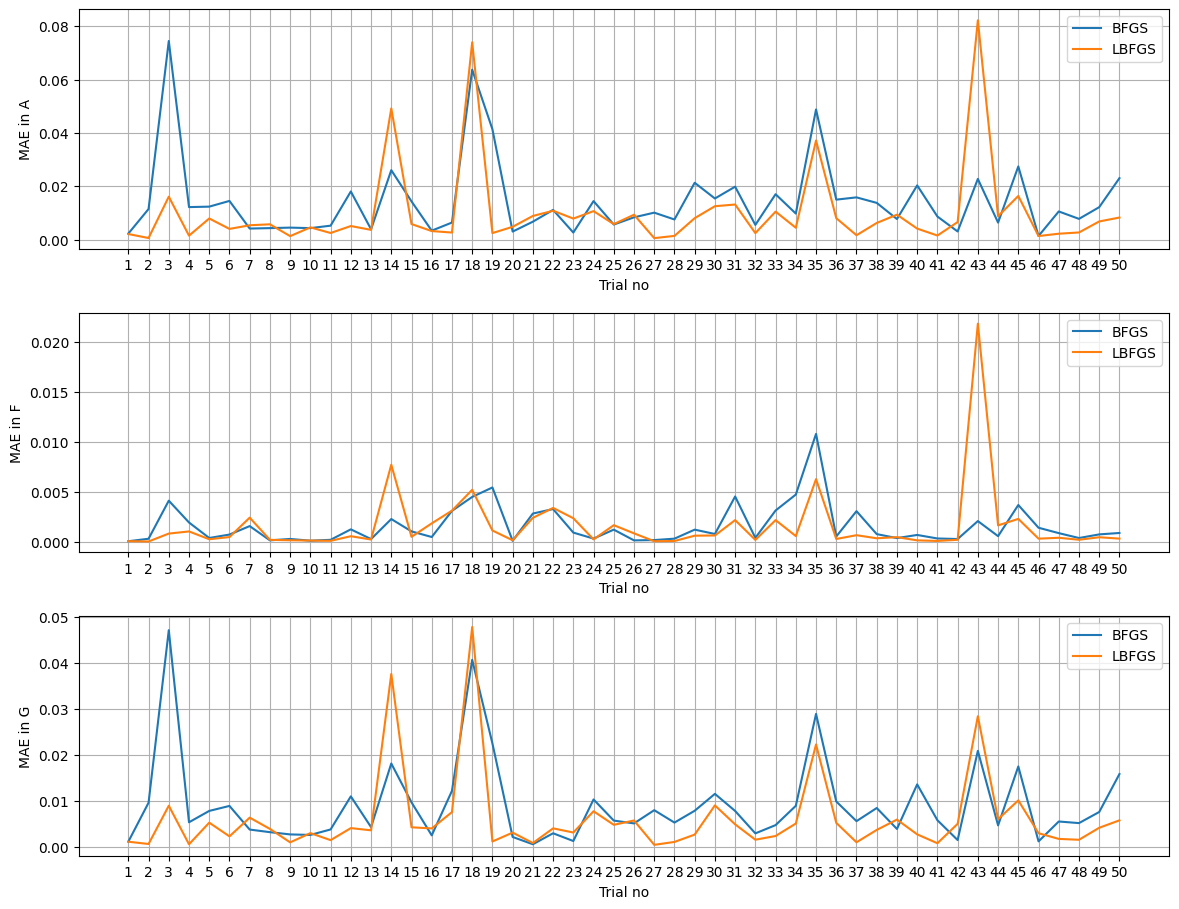

In [169]:
compare_methods(50, 15.0)